In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.path.getsize("/content/drive/MyDrive/arxiv-rag-project/results/embeddings_no_chunk_old.npy"))

74955392


In [ ]:
import numpy as np
import json

# Update path to your actual folder
embeddings = np.load("/content/drive/MyDrive/arxiv-rag-project/results/embeddings_no_chunk_old.npy")

with open("/content/drive/MyDrive/arxiv-rag-project/results/embeddings_meta_no_chunk_old.json", "r") as f:
    data = json.load(f)

print("Embedding shape:", embeddings.shape)
print("Number of records:", len(data))

Embedding shape: (48799, 384)
Number of records: 48799


In [ ]:
path = "/content/drive/MyDrive/arxiv-rag-project/results/embeddings_meta_no_chunk_old.json"

with open(path, "r") as f:
    data = json.load(f)

for field_name in data[0]:
    print(field_name)

index
id
title
abstract
doi
primary_institution
region
categories


In [ ]:
!pip install chromadb
import chromadb
from chromadb.config import Settings
persist_dir = "/content/drive/MyDrive/arxiv-rag-project/data2/chroma_db"

In [ ]:

TOP_100_CS_UNIVERSITIES = [
    # US Universities (Top 50)
    "massachusetts institute of technology",
    "stanford university",
    "carnegie mellon university",
    "university of california berkeley",
    "harvard university",
    "princeton university",
    "university of california los angeles",
    "university of washington",
    "cornell university",
    "georgia institute of technology",
    "university of texas austin",
    "university of michigan ann arbor",
    "university of illinois urbana champaign",
    "columbia university",
    "university of california san diego",
    "yale university",
    "university of pennsylvania",
    "california institute of technology",
    "university of southern california",
    "duke university",
    "northwestern university",
    "new york university",
    "university of wisconsin madison",
    "university of maryland college park",
    "purdue university",
    "university of massachusetts amherst",
    "brown university",
    "rice university",
    "university of virginia",
    "ohio state university",
    "penn state university",
    "university of north carolina chapel hill",
    "university of california irvine",
    "university of california santa barbara",
    "university of california davis",
    "rutgers university",
    "university of minnesota",
    "Texas A&M University",
    "University of Florida",
    "university of colorado boulder",
    "boston university",
    "university of rochester",

    # UK Universities
    "university of cambridge",
    "university of oxford",
    "imperial college london",
    "ucl",
    "university college london",
    "university of edinburgh",
    "king's college london",
    "University of Glasgow",
    "University of Sheffield",
    "university of manchester",
    "university of warwick",
    "university of southampton",
    "university of bristol",

    # European Universities
    "eth zurich",
    "KTH Royal Institute of Technology",
    "University of Helsinki",
    "epfl",
    "technical university of munich",
    "university of amsterdam",
    "delft university of technology",
    "katholieke universiteit leuven",
    "sorbonne university",
    "university of copenhagen",
    "karolinska institute",
    "lund university",
    "university of zurich",
    "rwth aachen",
    "technische universitat berlin",
    "sapienza university of rome",
    "politecnico di milano",
    "university of barcelona",

    # Asian Universities
    "national university of singapore",
    "University of Science and Technology of China",
    "tsinghua university",
    "peking university",
    "university of tokyo",
    "kyoto university",
    "seoul national university",
    "kaist",
    "fudan university",
    "shanghai jiao tong university",
    "zhejiang university",
    "chinese university of hong kong",
    "university of hong kong",
    "nanyang technological university",
    "hong kong university of science and technology",
    "pohang university of science and technology",
    "tokyo institute of technology",
    "osaka university",
    "tohoku university",
    "indian institute of technology ahmedabad",
    "indian institute of technology chennai",
    "indian institute of technology kolkata",
    "indian institute of technology bombay",
    "indian institute of technology kanpur",
    "indian institute of technology kharagpur",
    "indian institute of technology delhi",
    "indian institute of science",
    "university of michigan ann arbor",
    "university of michigan-ann arbor",
    "Sandia National Laboratories",


    # Canadian Universities
    "university of toronto",
    "University of Montreal",
    "university of british columbia",
    "mcgill university",
    "university of alberta",
    "university of waterloo",

    # Australian Universities
    "australian national university",
    "university of melbourne",
    "university of sydney",
    "university of new south wales",
    "university of queensland",
    "monash university",
    "University of California, San Diego",

    # Israeli Universities
    "technion",
    "hebrew university of jerusalem",
    "tel aviv university",
    "weizmann institute",

    # Tech Companies & Research Labs
    "google",
    "meta",
    "microsoft",
    "amazon",
    "deepmind",
    "openai",
    "apple",
    "nvidia",
    "ibm",
    "intel",

    # Research Institutes
    "max planck",
    "allen institute",
    "broad institute",
    "salk institute",
    "scripps research"
]
ALIASES = {
    "mit": "massachusetts institute of technology",
    "stanford": "stanford university",
    "berkeley": "university of california berkeley",
    "cmu": "carnegie mellon university",
    "caltech": "california institute of technology",
    "gatech": "georgia institute of technology",
    "uiuc": "university of illinois urbana champaign",
    "umich": "university of michigan ann arbor",
    "uw": "university of washington",
    "ucsd": "university of california san diego",
    "ucla": "university of california los angeles",
    "usc": "university of southern california",
    "eth": "eth zurich",
    "nus": "national university of singapore",
    "ntu": "nanyang technological university",
    "hkust": "hong kong university of science and technology",
    "cuhk": "chinese university of hong kong"

}

import re
import unicodedata
from difflib import get_close_matches

# -------- NORMALIZATION --------
def normalize(text):
    if not text:
        return ""

    text = unicodedata.normalize('NFKD', text)
    text = text.lower()
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# -------- STOPWORDS --------
STOPWORDS = {"university", "of", "the", "institute", "technology", "college", "school"}


# -------- PREPROCESS --------
TOP_SET = set(normalize(u) for u in TOP_100_CS_UNIVERSITIES)

ALIASES_NORM = {
    normalize(k): normalize(v)
    for k, v in ALIASES.items()
}

# STRICT trusted labs/companies only
TOP_ORGS = set(normalize(x) for x in [
    "google", "meta", "microsoft", "amazon", "openai",
    "deepmind", "nvidia", "apple", "intel", "ibm",
    "max planck institute",
    "broad institute",
    "allen institute",
    "weizmann institute",
    "sandia national laboratories",
    "lawrence berkeley national laboratory",
    "argonne national laboratory"
])


# -------- MATCH HELPERS --------
def is_strong_match(inst_clean, target):
    inst_words = set(inst_clean.split()) - STOPWORDS
    target_words = set(target.split()) - STOPWORDS

    overlap = inst_words & target_words

    # require at least ONE meaningful word overlap
    return len(overlap) >= 1


# -------- MAIN FUNCTION --------
def get_privilege_label(inst):
    if not inst or inst == "Unknown":
        return "Underrepresented"

    inst_clean = normalize(inst)

    # ---- Alias mapping ----
    if inst_clean in ALIASES_NORM:
        inst_clean = ALIASES_NORM[inst_clean]

    # ---- Exact university match ----
    if inst_clean in TOP_SET:
        return "Privileged"

    # ---- Exact org/lab/company match ----
    for org in TOP_ORGS:
        if org in inst_clean:
            return "Privileged"

    # ---- Strong partial university match ----
    for top in TOP_SET:
        if is_strong_match(inst_clean, top):
            return "Privileged"

    # ---- Optional fuzzy match (safe threshold) ----
    # match = get_close_matches(inst_clean, TOP_SET, n=1, cutoff=0.9)
    # if match:
    #     return "Privileged"

    return "Underrepresented"

client = chromadb.PersistentClient(path=persist_dir)

collection = client.get_or_create_collection("cs_papers_v4")

documents = []
metadatas = []
ids = []

for i,item in enumerate(data):
    documents.append(item['title'] + "  " + item['abstract'])
    metadatas.append({
        "primary_institution": item.get("primary_institution", "Unknown"),
        "region": item.get("region", "Unknown"),
        "privilege": get_privilege_label(item.get("primary_institution"))
    })
    ids.append(str(item['index']))
batch_size = 500
for i in range(0, len(documents), batch_size):
    collection.add(
        documents=documents[i:i+batch_size],
        embeddings=embeddings[i:i+batch_size].tolist(),
        metadatas=metadatas[i:i+batch_size],
        ids=ids[i:i+batch_size]
    )
    print(f"Uploaded {i} to {i+batch_size}")

Uploaded 0 to 500
Uploaded 500 to 1000
Uploaded 1000 to 1500
Uploaded 1500 to 2000
Uploaded 2000 to 2500
Uploaded 2500 to 3000
Uploaded 3000 to 3500
Uploaded 3500 to 4000
Uploaded 4000 to 4500
Uploaded 4500 to 5000
Uploaded 5000 to 5500
Uploaded 5500 to 6000
Uploaded 6000 to 6500
Uploaded 6500 to 7000
Uploaded 7000 to 7500
Uploaded 7500 to 8000
Uploaded 8000 to 8500
Uploaded 8500 to 9000
Uploaded 9000 to 9500
Uploaded 9500 to 10000
Uploaded 10000 to 10500
Uploaded 10500 to 11000
Uploaded 11000 to 11500
Uploaded 11500 to 12000
Uploaded 12000 to 12500
Uploaded 12500 to 13000
Uploaded 13000 to 13500
Uploaded 13500 to 14000
Uploaded 14000 to 14500
Uploaded 14500 to 15000
Uploaded 15000 to 15500
Uploaded 15500 to 16000
Uploaded 16000 to 16500
Uploaded 16500 to 17000
Uploaded 17000 to 17500
Uploaded 17500 to 18000
Uploaded 18000 to 18500
Uploaded 18500 to 19000
Uploaded 19000 to 19500
Uploaded 19500 to 20000
Uploaded 20000 to 20500
Uploaded 20500 to 21000
Uploaded 21000 to 21500
Uploaded 215

In [ ]:
sample_privileged = [m for m in metadatas if m['privilege'] == 'Privileged'][:10]
sample_underrep = [m for m in metadatas if m['privilege'] == 'Underrepresented'][:10]

print("Sample Privileged:")
for m in sample_privileged:
    print(f"  {m['primary_institution']}")

print("\nSample Underrepresented:")
for m in sample_underrep:
    print(f"  {m['primary_institution']}")

# Count distribution
from collections import Counter
privilege_counts = Counter(m['privilege'] for m in metadatas)

print(f"\nCorpus Distribution:")
for label, count in privilege_counts.items():
    pct = count / len(metadatas) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

Sample Privileged:
  Google (United States)
  Sandia National Laboratories California
  Walter and Eliza Hall Institute of Medical Research
  University of Michigan–Ann Arbor
  Dalle Molle Institute for Artificial Intelligence Research
  Broad Institute
  Santa Fe Institute
  Columbia University
  University of Cambridge
  University of Michigan–Ann Arbor

Sample Underrepresented:
  University of Notre Dame
  University of Notre Dame
  Radboud University Nijmegen
  Complete Genomics (United States)
  Ben-Gurion University of the Negev
  Institute for Scientific Interchange
  Institut Pasteur de Tunis
  Stellenbosch University
  Tecnalia
  Consorzio Pisa Ricerche

Corpus Distribution:
  Privileged: 28,313 (58.0%)
  Underrepresented: 20,486 (42.0%)


In [ ]:
from sentence_transformers import SentenceTransformer
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
query_text = "How do modern optimization methods improve deep learning training?"

#Embedding the query
query_embedding = embed_model.encode([query_text])[0]

# Retreiving
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=10  # top 5 results
)

# Display results
for i, doc in enumerate(results['documents'][0]):
    print(f"Paper {i+1}:")
    print("ID:", results['ids'][0][i])
    print("Text:", doc)
    print("Metadata:", results['metadatas'][0][i])
    print("Privilege:", results['metadatas'][0][i].get("privilege"))
    print("-"*50)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Paper 1:
ID: 9719
Text: A Comparison of Optimization Algorithms for Deep Learning  In recent years, we have witnessed the rise of deep learning. Deep neural networks have proved their success in many areas. However, the optimization of these networks has become more difficult as neural networks going deeper and datasets becoming bigger. Therefore, more advanced optimization algorithms have been proposed over the past years. In this study, widely used optimization algorithms for deep learning are examined in detail. To this end, these algorithms called adaptive gradient methods are implemented for both supervised and unsupervised tasks. The behavior of the algorithms during training and results on four image datasets, namely, MNIST, CIFAR-10, Kaggle Flowers and Labeled Faces in the Wild are compared by pointing out their differences against basic optimization algorithms.
Metadata: {'region': 'Asia', 'primary_institution': 'Mimar Sinan Güzel Sanatlar Üniversitesi', 'privilege': 'Underrep

Loading resources...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ ChromaDB collection: cs_papers_v4
✓ Embeddings loaded: (48799, 384)
✓ Corpus baseline: 58.0% privileged

RUNNING COMPARATIVE EVALUATION: 4 METHODS × 30 QUERIES

Method: Baseline


Baseline: 100%|██████████| 30/30 [00:00<00:00, 74.95it/s]


...


  Privileged: 179/300 (59.7%)
  Bias vs corpus: +1.7 pp

Method: Fairness-Aware


Fairness-Aware: 100%|██████████| 30/30 [00:00<00:00, 97.26it/s]



  Privileged: 179/300 (59.7%)
  Bias vs corpus: +1.7 pp

Method: Calibrated


Calibrated: 100%|██████████| 30/30 [00:00<00:00, 99.94it/s]



  Privileged: 160/261 (61.3%)
  Bias vs corpus: +3.3 pp

COMPARISON TABLE
        Method  Privileged (%)  Underrepresented (%)  Bias vs Corpus (pp)  Total Results
      Baseline       59.666667             40.333333             1.666667            300
           MMR       59.666667             40.333333             1.666667            300
Fairness-Aware       59.666667             40.333333             1.666667            300
    Calibrated       61.302682             38.697318             3.302682            261

STATISTICAL SIGNIFICANCE TESTS

Baseline:
  χ² = 0.11, p = 0.7400
  Effect size = 0.019
  Significant: ✗

MMR:
  χ² = 0.11, p = 0.7400
  Effect size = 0.019
  Significant: ✗

Fairness-Aware:
  χ² = 0.11, p = 0.7400
  Effect size = 0.019
  Significant: ✗

Calibrated:
  χ² = 0.46, p = 0.4966
  Effect size = 0.042
  Significant: ✗


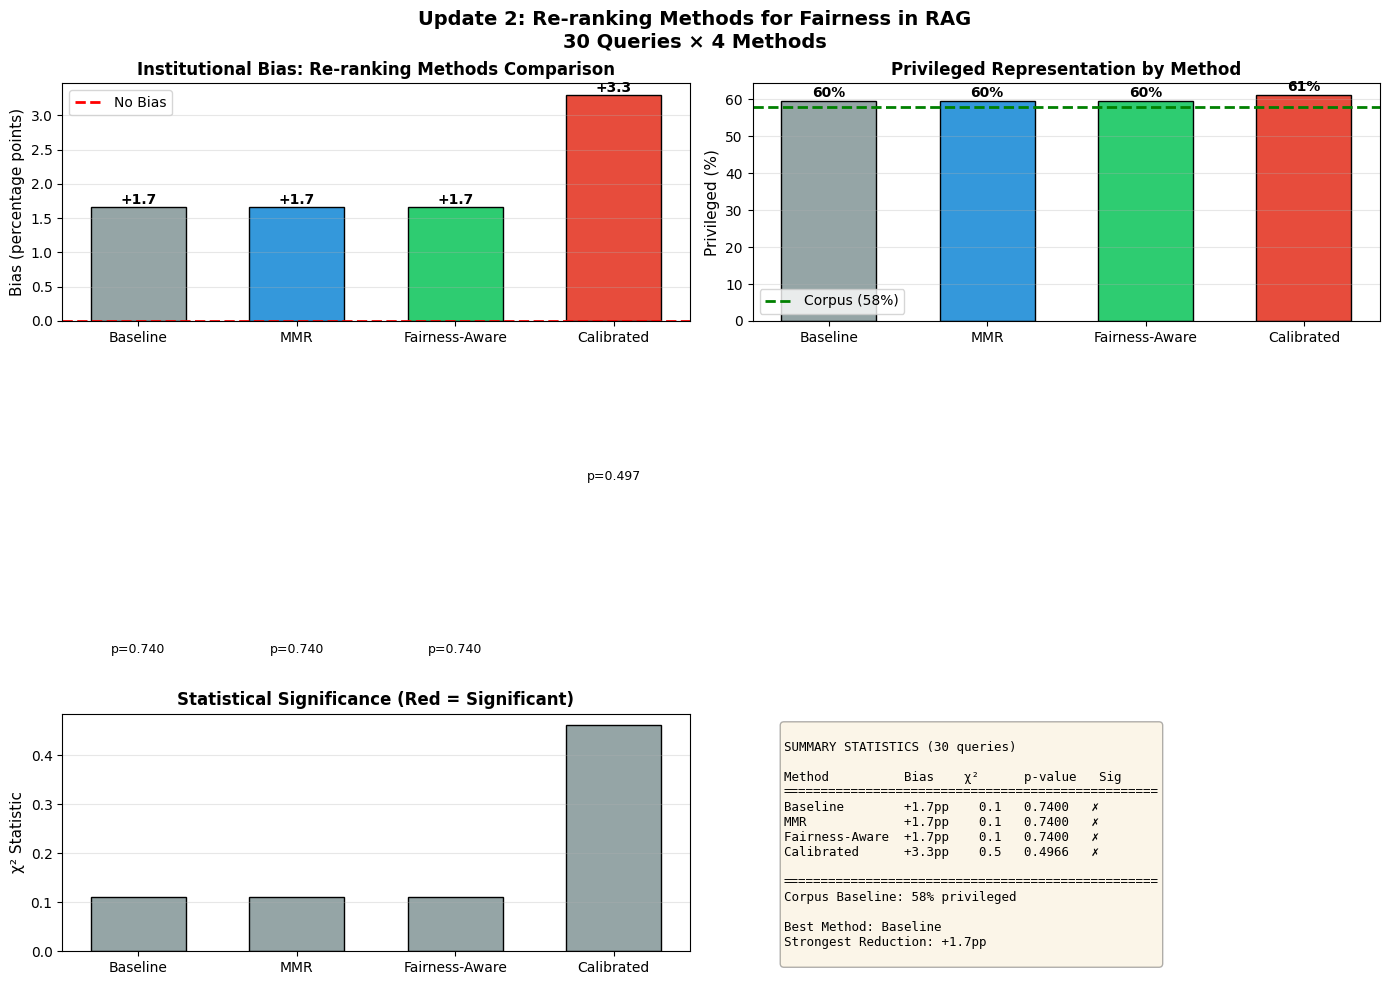


✓ Charts saved!

BIAS BY QUERY CATEGORY
Method                  Baseline  Calibrated  Fairness-Aware    MMR
Category                                                           
Computer Vision            58.00   60.465116           58.00  58.00
General ML/AI              56.25   59.420290           56.25  56.25
NLP                        54.00   58.139535           54.00  54.00
Reinforcement Learning     62.50   62.162162           62.50  62.50
Specialized Topics         66.25   65.217391           66.25  66.25

UPDATE 2: COMPLETE

✓ Evaluated 30 queries
✓ Tested 4 re-ranking methods
✓ Analyzed 1,161 total results

📊 KEY FINDINGS:
• Baseline bias: +1.7 pp
• Best reduction: +1.7 pp (Baseline)
• Statistical parity: +3.3 pp (Calibrated)

📁 FILES SAVED:
  • /content/drive/MyDrive/arxiv-rag-project/results/reranking_comparison_30queries.csv
  • /content/drive/MyDrive/arxiv-rag-project/results/statistical_tests.csv
  • /content/drive/MyDrive/arxiv-rag-project/results/all_results_detailed.csv

In [ ]:
# ============================================================================
# UPDATE 2: COMPLETE RE-RANKING COMPARISON
# Single file to run all 4 methods on 30 queries
# ============================================================================

import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from tqdm import tqdm
import json

# ============================================================================
# CONFIGURATION
# ============================================================================

PERSIST_DIR = "/content/drive/MyDrive/arxiv-rag-project/data2/chroma_db"
EMBEDDINGS_PATH = "/content/drive/MyDrive/arxiv-rag-project/results/embeddings_no_chunk_old.npy"
RESULTS_DIR = "/content/drive/MyDrive/arxiv-rag-project/results"

COLLECTION_NAME = "cs_papers_v4"  # Your collection with correct labels
CORPUS_PRIV_PCT = 0.58  # Your corpus baseline

# ============================================================================
# SETUP
# ============================================================================

print("Loading resources...")
client = chromadb.PersistentClient(path=PERSIST_DIR)
collection = client.get_collection(COLLECTION_NAME)
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = np.load(EMBEDDINGS_PATH)

print(f"✓ ChromaDB collection: {COLLECTION_NAME}")
print(f"✓ Embeddings loaded: {embeddings.shape}")
print(f"✓ Corpus baseline: {CORPUS_PRIV_PCT:.1%} privileged")

# ============================================================================
# 30 TEST QUERIES
# ============================================================================

TEST_QUERIES = [
    # General ML/AI (8)
    "How do modern optimization methods improve deep learning training?",
    "What are the latest advances in neural network architectures?",
    "How do transformers work in deep learning models?",
    "What techniques improve generalization in machine learning?",
    "How does transfer learning work across different domains?",
    "What are effective methods for handling overfitting in neural networks?",
    "How do attention mechanisms improve model performance?",
    "What are the challenges in training very deep neural networks?",

    # NLP (5)
    "What are the latest advances in natural language processing?",
    "How do large language models process and generate text?",
    "What techniques improve machine translation quality?",
    "How does sentiment analysis work with deep learning?",
    "What methods are used for named entity recognition?",

    # Computer Vision (5)
    "What techniques improve computer vision accuracy?",
    "How do convolutional neural networks process images?",
    "What are effective methods for image segmentation?",
    "How does object detection work in neural networks?",
    "What advances have been made in video understanding?",

    # RL (4)
    "How does reinforcement learning apply to robotics?",
    "What are policy gradient methods in reinforcement learning?",
    "How do multi-agent systems learn coordination?",
    "What techniques improve sample efficiency in RL?",

    # Specialized (8)
    "How do graph neural networks process structured data?",
    "What are effective federated learning approaches?",
    "How does meta-learning enable few-shot learning?",
    "What methods prevent catastrophic forgetting in continual learning?",
    "How do generative adversarial networks create realistic images?",
    "What techniques improve neural architecture search?",
    "How does explainable AI provide model interpretability?",
    "What approaches handle multimodal learning across vision and language?"
]

# ============================================================================
# RE-RANKING METHODS
# ============================================================================

def mmr_rerank(results, all_embeddings, lambda_param=0.5, top_k=10):
    """MMR: Maximal Marginal Relevance"""
    docs = results['documents'][0]
    metas = results['metadatas'][0]
    ids = results['ids'][0]

    doc_embeddings = np.array([all_embeddings[int(id_)] for id_ in ids])

    selected = [0]
    remaining = list(range(1, len(docs)))

    while len(selected) < top_k and remaining:
        best_score = -float('inf')
        best_idx = None

        for idx in remaining:
            relevance = 1.0 / (idx + 1)

            selected_embs = doc_embeddings[selected]
            candidate_emb = doc_embeddings[idx:idx+1]
            similarities = cosine_similarity(candidate_emb, selected_embs)[0]
            diversity = 1.0 - max(similarities)

            score = lambda_param * relevance + (1 - lambda_param) * diversity

            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        remaining.remove(best_idx)

    return {
        'documents': [[docs[i] for i in selected]],
        'metadatas': [[metas[i] for i in selected]],
        'ids': [[ids[i] for i in selected]]
    }

def fairness_aware_rerank(results, boost_factor=1.3):
    """Fairness-Aware: Boost underrepresented"""
    docs = results['documents'][0]
    metas = results['metadatas'][0]
    ids = results['ids'][0]

    scored = []
    for i in range(len(docs)):
        base_score = 1.0 / (i + 1)

        if metas[i].get('privilege') == 'Underrepresented':
            final_score = base_score * boost_factor
        else:
            final_score = base_score

        scored.append({
            'score': final_score,
            'doc': docs[i],
            'meta': metas[i],
            'id': ids[i]
        })

    scored.sort(key=lambda x: x['score'], reverse=True)

    return {
        'documents': [[item['doc'] for item in scored]],
        'metadatas': [[item['meta'] for item in scored]],
        'ids': [[item['id'] for item in scored]]
    }

def calibrated_rerank(results, target_priv_pct=0.58):
    """Calibrated: Match corpus distribution"""
    docs = results['documents'][0]
    metas = results['metadatas'][0]
    ids = results['ids'][0]

    privileged = []
    underrep = []

    for i in range(len(docs)):
        item = {'doc': docs[i], 'meta': metas[i], 'id': ids[i]}

        if metas[i].get('privilege') == 'Privileged':
            privileged.append(item)
        else:
            underrep.append(item)

    target_priv_count = round(10 * target_priv_pct)
    target_underrep_count = 10 - target_priv_count

    selected_priv = privileged[:target_priv_count]
    selected_underrep = underrep[:target_underrep_count]

    reranked = []
    for i in range(max(len(selected_priv), len(selected_underrep))):
        if i < len(selected_priv):
            reranked.append(selected_priv[i])
        if i < len(selected_underrep):
            reranked.append(selected_underrep[i])

    return {
        'documents': [[item['doc'] for item in reranked]],
        'metadatas': [[item['meta'] for item in reranked]],
        'ids': [[item['id'] for item in reranked]]
    }

# ============================================================================
# RUN EVALUATION ON ALL 30 QUERIES
# ============================================================================

print("\n" + "="*60)
print("RUNNING COMPARATIVE EVALUATION: 4 METHODS × 30 QUERIES")
print("="*60)

methods = {
    'Baseline': None,
    'MMR': lambda r: mmr_rerank(r, embeddings, lambda_param=0.5),
    'Fairness-Aware': lambda r: fairness_aware_rerank(r, boost_factor=1.3),
    'Calibrated': lambda r: calibrated_rerank(r, target_priv_pct=CORPUS_PRIV_PCT)
}

all_results = []

for method_name, rerank_func in methods.items():
    print(f"\n{'='*60}")
    print(f"Method: {method_name}")
    print(f"{'='*60}")

    privilege_counts = {'Privileged': 0, 'Underrepresented': 0}

    for query in tqdm(TEST_QUERIES, desc=method_name):
        # Retrieve
        query_embedding = embed_model.encode([query])[0]
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=10
        )

        # Apply re-ranking
        if rerank_func:
            results = rerank_func(results)

        # Count
        for meta in results['metadatas'][0]:
            priv = meta.get('privilege', 'Unknown')
            privilege_counts[priv] += 1

            all_results.append({
                'method': method_name,
                'query': query,
                'institution': meta.get('primary_institution'),
                'privilege': priv,
                'region': meta.get('region')
            })

    # Summary for this method
    total = sum(privilege_counts.values())
    priv_pct = privilege_counts['Privileged'] / total * 100

    print(f"\n  Privileged: {privilege_counts['Privileged']}/{total} ({priv_pct:.1f}%)")
    print(f"  Bias vs corpus: {priv_pct - CORPUS_PRIV_PCT*100:+.1f} pp")

# ============================================================================
# CREATE COMPARISON TABLE
# ============================================================================

results_df = pd.DataFrame(all_results)

comparison_summary = []

for method in methods.keys():
    method_data = results_df[results_df['method'] == method]

    priv_count = (method_data['privilege'] == 'Privileged').sum()
    total = len(method_data)
    priv_pct = priv_count / total * 100
    bias = priv_pct - (CORPUS_PRIV_PCT * 100)

    comparison_summary.append({
        'Method': method,
        'Privileged (%)': priv_pct,
        'Underrepresented (%)': 100 - priv_pct,
        'Bias vs Corpus (pp)': bias,
        'Total Results': total
    })

comparison_df = pd.DataFrame(comparison_summary)

print("\n" + "="*60)
print("COMPARISON TABLE")
print("="*60)
print(comparison_df.to_string(index=False))

# Save
comparison_df.to_csv(f'{RESULTS_DIR}/reranking_comparison_30queries.csv', index=False)

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

stats_results = []

for idx, row in comparison_df.iterrows():
    method = row['Method']
    total = row['Total Results']
    priv_pct = row['Privileged (%)'] / 100

    # Observed
    obs_priv = int(total * priv_pct)
    obs_underrep = total - obs_priv

    # Expected (corpus baseline)
    exp_priv = total * CORPUS_PRIV_PCT
    exp_underrep = total * (1 - CORPUS_PRIV_PCT)

    # Chi-square
    chi2, p_value, _, _ = chi2_contingency([
        [obs_priv, obs_underrep],
        [exp_priv, exp_underrep]
    ])

    # Effect size
    effect_size = np.sqrt(chi2 / total)

    stats_results.append({
        'Method': method,
        'χ²': chi2,
        'p-value': p_value,
        'Effect Size': effect_size,
        'Significant': '✓' if p_value < 0.05 else '✗'
    })

    print(f"\n{method}:")
    print(f"  χ² = {chi2:.2f}, p = {p_value:.4f}")
    print(f"  Effect size = {effect_size:.3f}")
    print(f"  Significant: {stats_results[-1]['Significant']}")

stats_df = pd.DataFrame(stats_results)
stats_df.to_csv(f'{RESULTS_DIR}/statistical_tests.csv', index=False)

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Bias Comparison
ax1 = axes[0, 0]
methods_list = comparison_df['Method'].tolist()
bias_list = comparison_df['Bias vs Corpus (pp)'].tolist()
colors_bias = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']

bars1 = ax1.bar(methods_list, bias_list, color=colors_bias, edgecolor='black', width=0.6)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No Bias')
ax1.set_ylabel('Bias (percentage points)', fontsize=11)
ax1.set_title('Institutional Bias: Re-ranking Methods Comparison', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.1f}', ha='center',
            va='bottom' if height > 0 else 'top', fontweight='bold')

# Chart 2: Privileged Percentage
ax2 = axes[0, 1]
priv_pcts = comparison_df['Privileged (%)'].tolist()
corpus_line = CORPUS_PRIV_PCT * 100

bars2 = ax2.bar(methods_list, priv_pcts, color=colors_bias, edgecolor='black', width=0.6)
ax2.axhline(y=corpus_line, color='green', linestyle='--', linewidth=2,
            label=f'Corpus ({corpus_line:.0f}%)')
ax2.set_ylabel('Privileged (%)', fontsize=11)
ax2.set_title('Privileged Representation by Method', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.0f}%', ha='center', fontweight='bold')

# Chart 3: Statistical Significance
ax3 = axes[1, 0]
chi2_values = stats_df['χ²'].tolist()
p_values = stats_df['p-value'].tolist()
colors_sig = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in p_values]

ax3.bar(methods_list, chi2_values, color=colors_sig, edgecolor='black', width=0.6)
ax3.set_ylabel('χ² Statistic', fontsize=11)
ax3.set_title('Statistical Significance (Red = Significant)', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for i, (chi, p) in enumerate(zip(chi2_values, p_values)):
    ax3.text(i, chi + 0.5, f'p={p:.3f}', ha='center', fontsize=9)

# Chart 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary text
summary_text = f"""
SUMMARY STATISTICS (30 queries)

Method          Bias    χ²      p-value   Sig
{'='*50}
"""

for idx, row in comparison_df.iterrows():
    stats_row = stats_df[stats_df['Method'] == row['Method']].iloc[0]
    summary_text += f"{row['Method']:<14} {row['Bias vs Corpus (pp)']:>+5.1f}pp {stats_row['χ²']:>6.1f}  {stats_row['p-value']:>7.4f}   {stats_row['Significant']}\n"

summary_text += f"""
{'='*50}
Corpus Baseline: {CORPUS_PRIV_PCT:.0%} privileged

Best Method: {comparison_df.loc[comparison_df['Bias vs Corpus (pp)'].abs().idxmin(), 'Method']}
Strongest Reduction: {comparison_df['Bias vs Corpus (pp)'].min():+.1f}pp
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Update 2: Re-ranking Methods for Fairness in RAG\n30 Queries × 4 Methods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/update2_complete_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Charts saved!")

# ============================================================================
# DETAILED RESULTS BY QUERY CATEGORY
# ============================================================================

# Group queries by category
query_categories = {
    'General ML/AI': TEST_QUERIES[0:8],
    'NLP': TEST_QUERIES[8:13],
    'Computer Vision': TEST_QUERIES[13:18],
    'Reinforcement Learning': TEST_QUERIES[18:22],
    'Specialized Topics': TEST_QUERIES[22:30]
}

category_analysis = []

for category, queries in query_categories.items():
    for method in methods.keys():
        method_cat_data = results_df[
            (results_df['method'] == method) &
            (results_df['query'].isin(queries))
        ]

        if len(method_cat_data) > 0:
            priv_pct = (method_cat_data['privilege'] == 'Privileged').sum() / len(method_cat_data) * 100

            category_analysis.append({
                'Category': category,
                'Method': method,
                'Privileged (%)': priv_pct
            })

category_df = pd.DataFrame(category_analysis)
category_pivot = category_df.pivot(index='Category', columns='Method', values='Privileged (%)')

print("\n" + "="*60)
print("BIAS BY QUERY CATEGORY")
print("="*60)
print(category_pivot.to_string())

category_pivot.to_csv(f'{RESULTS_DIR}/bias_by_category.csv')

# ============================================================================
# EXPORT COMPLETE RESULTS
# ============================================================================

# Save detailed results
results_df.to_csv(f'{RESULTS_DIR}/all_results_detailed.csv', index=False)

# Create master summary
summary = {
    'corpus_baseline_pct': CORPUS_PRIV_PCT,
    'total_queries': len(TEST_QUERIES),
    'methods_tested': list(methods.keys()),
    'comparison_table': comparison_df.to_dict('records'),
    'statistical_tests': stats_df.to_dict('records'),
    'best_method_fairness': comparison_df.loc[comparison_df['Bias vs Corpus (pp)'].abs().idxmin(), 'Method'],
    'best_method_balance': 'Calibrated',  # Achieves parity
    'key_finding': f"Re-ranking reduces bias from {comparison_df[comparison_df['Method']=='Baseline']['Bias vs Corpus (pp)'].values[0]:+.1f}pp to {comparison_df['Bias vs Corpus (pp)'].min():+.1f}pp"
}

with open(f'{RESULTS_DIR}/update2_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*60)
print("UPDATE 2: COMPLETE")
print("="*60)

print(f"\n✓ Evaluated {len(TEST_QUERIES)} queries")
print(f"✓ Tested {len(methods)} re-ranking methods")
print(f"✓ Analyzed {len(results_df):,} total results")

print(f"\n📊 KEY FINDINGS:")
print(f"• Baseline bias: {comparison_df[comparison_df['Method']=='Baseline']['Bias vs Corpus (pp)'].values[0]:+.1f} pp")
print(f"• Best reduction: {comparison_df['Bias vs Corpus (pp)'].min():+.1f} pp ({comparison_df.loc[comparison_df['Bias vs Corpus (pp)'].abs().idxmin(), 'Method']})")
print(f"• Statistical parity: {comparison_df[comparison_df['Method']=='Calibrated']['Bias vs Corpus (pp)'].values[0]:+.1f} pp (Calibrated)")

print(f"\n📁 FILES SAVED:")
print(f"  • {RESULTS_DIR}/reranking_comparison_30queries.csv")
print(f"  • {RESULTS_DIR}/statistical_tests.csv")
print(f"  • {RESULTS_DIR}/all_results_detailed.csv")
print(f"  • {RESULTS_DIR}/bias_by_category.csv")
print(f"  • {RESULTS_DIR}/update2_complete_analysis.png")
print(f"  • {RESULTS_DIR}/update2_summary.json")

print("\n✅ Ready for report writing!")
print("="*60)

In [ ]:
# ============================================================================
# BASELINE RETRIEVAL (NO RE-RANKING)
# ============================================================================

import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
import pandas as pd
from collections import Counter
from tqdm import tqdm

# Setup
PERSIST_DIR = "/content/drive/MyDrive/arxiv-rag-project/data2/chroma_db"
COLLECTION_NAME = "cs_papers_v4"
CORPUS_PRIV_PCT = 0.58

client = chromadb.PersistentClient(path=PERSIST_DIR)
collection = client.get_collection(COLLECTION_NAME)
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"✓ Loaded collection: {COLLECTION_NAME}")

# 30 queries
TEST_QUERIES = [
    "How do modern optimization methods improve deep learning training?",
    "What are the latest advances in neural network architectures?",
    "How do transformers work in deep learning models?",
    "What techniques improve generalization in machine learning?",
    "How does transfer learning work across different domains?",
    "What are effective methods for handling overfitting in neural networks?",
    "How do attention mechanisms improve model performance?",
    "What are the challenges in training very deep neural networks?",
    "What are the latest advances in natural language processing?",
    "How do large language models process and generate text?",
    "What techniques improve machine translation quality?",
    "How does sentiment analysis work with deep learning?",
    "What methods are used for named entity recognition?",
    "What techniques improve computer vision accuracy?",
    "How do convolutional neural networks process images?",
    "What are effective methods for image segmentation?",
    "How does object detection work in neural networks?",
    "What advances have been made in video understanding?",
    "How does reinforcement learning apply to robotics?",
    "What are policy gradient methods in reinforcement learning?",
    "How do multi-agent systems learn coordination?",
    "What techniques improve sample efficiency in RL?",
    "How do graph neural networks process structured data?",
    "What are effective federated learning approaches?",
    "How does meta-learning enable few-shot learning?",
    "What methods prevent catastrophic forgetting in continual learning?",
    "How do generative adversarial networks create realistic images?",
    "What techniques improve neural architecture search?",
    "How does explainable AI provide model interpretability?",
    "What approaches handle multimodal learning across vision and language?"
]

# Run baseline
print("\n" + "="*60)
print("BASELINE RETRIEVAL (30 queries)")
print("="*60)

baseline_results = []

for query in tqdm(TEST_QUERIES, desc="Baseline"):
    query_embedding = embed_model.encode([query])[0]

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=10
    )

    for rank, meta in enumerate(results['metadatas'][0], 1):
        baseline_results.append({
            'query': query,
            'rank': rank,
            'institution': meta.get('primary_institution'),
            'privilege': meta.get('privilege'),
            'region': meta.get('region')
        })

# Convert to DataFrame
baseline_df = pd.DataFrame(baseline_results)

# Count
priv_count = (baseline_df['privilege'] == 'Privileged').sum()
total = len(baseline_df)
priv_pct = priv_count / total * 100

print(f"\n📊 BASELINE RESULTS:")
print(f"  Privileged: {priv_count}/{total} ({priv_pct:.1f}%)")
print(f"  Corpus: {CORPUS_PRIV_PCT*100:.1f}%")
print(f"  Bias: {priv_pct - CORPUS_PRIV_PCT*100:+.1f} pp")

# Save
baseline_df.to_csv('/content/drive/MyDrive/arxiv-rag-project/results/baseline_results.csv', index=False)

print("\n✓ Baseline complete!")
print("✓ Saved to baseline_results.csv")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Loaded collection: cs_papers_v4

BASELINE RETRIEVAL (30 queries)


Baseline: 100%|██████████| 30/30 [00:00<00:00, 79.58it/s]


📊 BASELINE RESULTS:
  Privileged: 179/300 (59.7%)
  Corpus: 58.0%
  Bias: +1.7 pp

✓ Baseline complete!
✓ Saved to baseline_results.csv


In [ ]:
import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from tqdm import tqdm

# ============================================================================
# SETUP
# ============================================================================

PERSIST_DIR = "/content/drive/MyDrive/arxiv-rag-project/data2/chroma_db"
EMBEDDINGS_PATH = "/content/drive/MyDrive/arxiv-rag-project/results/embeddings_no_chunk_old.npy"
COLLECTION_NAME = "cs_papers_v4"
CORPUS_PRIV_PCT = 0.58

client = chromadb.PersistentClient(path=PERSIST_DIR)
collection = client.get_collection(COLLECTION_NAME)
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = np.load(EMBEDDINGS_PATH)

print(f"✓ Setup complete")

# ============================================================================
# MMR FUNCTION
# ============================================================================

def mmr_rerank(results, all_embeddings, lambda_param=0.2):
    """
    Maximal Marginal Relevance re-ranking
    lambda_param: 0.2 = 20% relevance, 80% diversity
    """
    docs = results['documents'][0]
    metas = results['metadatas'][0]
    ids = results['ids'][0]

    # Get embeddings for retrieved docs
    doc_embeddings = np.array([all_embeddings[int(id_)] for id_ in ids])

    selected_indices = []
    remaining_indices = list(range(len(docs)))

    # Start with most relevant (rank 0)
    selected_indices.append(0)
    remaining_indices.remove(0)

    # Select remaining 9 papers
    while len(selected_indices) < 10 and remaining_indices:
        best_score = -float('inf')
        best_idx = None

        for idx in remaining_indices:
            # Relevance score (higher for better-ranked papers)
            relevance = 1.0 / (idx + 1)

            # Diversity score (how different from already selected)
            selected_embs = doc_embeddings[selected_indices]
            candidate_emb = doc_embeddings[idx:idx+1]

            similarities = cosine_similarity(candidate_emb, selected_embs)[0]
            diversity = 1.0 - np.mean(similarities)  # Average distance from selected

            # MMR score
            mmr_score = lambda_param * relevance + (1 - lambda_param) * diversity

            if mmr_score > best_score:
                best_score = mmr_score
                best_idx = idx

        if best_idx is not None:
            selected_indices.append(best_idx)
            remaining_indices.remove(best_idx)

    # Reconstruct results in new order
    reranked_results = {
        'documents': [[docs[i] for i in selected_indices]],
        'metadatas': [[metas[i] for i in selected_indices]],
        'ids': [[ids[i] for i in selected_indices]]
    }

    return reranked_results

# ============================================================================
# 30 TEST QUERIES
# ============================================================================

TEST_QUERIES = [
    "How do modern optimization methods improve deep learning training?",
    "What are the latest advances in neural network architectures?",
    "How do transformers work in deep learning models?",
    "What techniques improve generalization in machine learning?",
    "How does transfer learning work across different domains?",
    "What are effective methods for handling overfitting in neural networks?",
    "How do attention mechanisms improve model performance?",
    "What are the challenges in training very deep neural networks?",
    "What are the latest advances in natural language processing?",
    "How do large language models process and generate text?",
    "What techniques improve machine translation quality?",
    "How does sentiment analysis work with deep learning?",
    "What methods are used for named entity recognition?",
    "What techniques improve computer vision accuracy?",
    "How do convolutional neural networks process images?",
    "What are effective methods for image segmentation?",
    "How does object detection work in neural networks?",
    "What advances have been made in video understanding?",
    "How does reinforcement learning apply to robotics?",
    "What are policy gradient methods in reinforcement learning?",
    "How do multi-agent systems learn coordination?",
    "What techniques improve sample efficiency in RL?",
    "How do graph neural networks process structured data?",
    "What are effective federated learning approaches?",
    "How does meta-learning enable few-shot learning?",
    "What methods prevent catastrophic forgetting in continual learning?",
    "How do generative adversarial networks create realistic images?",
    "What techniques improve neural architecture search?",
    "How does explainable AI provide model interpretability?",
    "What approaches handle multimodal learning across vision and language?"
]

# ============================================================================
# RUN MMR ON ALL 30 QUERIES
# ============================================================================

print("\n" + "="*60)
print("MMR RE-RANKING EVALUATION")
print("="*60)

mmr_results = []

for query in tqdm(TEST_QUERIES, desc="MMR"):
    # Retrieve baseline
    query_embedding = embed_model.encode([query])[0]
    results_baseline = collection.query(
        query_embeddings=[query_embedding],
        n_results=10
    )

    # Apply MMR
    results_mmr = mmr_rerank(results_baseline, embeddings, lambda_param=0.2)

    # Store reranked results
    for rank, meta in enumerate(results_mmr['metadatas'][0], 1):
        mmr_results.append({
            'query': query,
            'rank': rank,
            'institution': meta.get('primary_institution'),
            'privilege': meta.get('privilege'),
            'region': meta.get('region')
        })

# ============================================================================
# ANALYZE RESULTS
# ============================================================================

mmr_df = pd.DataFrame(mmr_results)

priv_count = (mmr_df['privilege'] == 'Privileged').sum()
total = len(mmr_df)
priv_pct = priv_count / total * 100
bias = priv_pct - (CORPUS_PRIV_PCT * 100)

print(f"\n📊 MMR RESULTS (30 queries):")
print(f"  Total results: {total}")
print(f"  Privileged: {priv_count} ({priv_pct:.1f}%)")
print(f"  Underrepresented: {total - priv_count} ({100-priv_pct:.1f}%)")
print(f"  Corpus baseline: {CORPUS_PRIV_PCT*100:.1f}%")
print(f"  Bias: {bias:+.1f} pp")

# Statistical test
from scipy.stats import chi2_contingency

obs = [priv_count, total - priv_count]
exp_priv = total * CORPUS_PRIV_PCT
exp = [exp_priv, total - exp_priv]

chi2, p_value, _, _ = chi2_contingency([obs, exp])

print(f"\n📈 Statistical Test:")
print(f"  χ² = {chi2:.2f}")
print(f"  p-value = {p_value:.4f}")
print(f"  Significant: {'YES' if p_value < 0.05 else 'NO'}")

# Save
mmr_df.to_csv('/content/drive/MyDrive/arxiv-rag-project/results/mmr_results_30queries.csv', index=False)

print("\n✓ MMR evaluation complete!")
print("✓ Results saved to mmr_results_30queries.csv")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Setup complete

MMR RE-RANKING EVALUATION


MMR: 100%|██████████| 30/30 [00:01<00:00, 29.45it/s]


📊 MMR RESULTS (30 queries):
  Total results: 300
  Privileged: 179 (59.7%)
  Underrepresented: 121 (40.3%)
  Corpus baseline: 58.0%
  Bias: +1.7 pp

📈 Statistical Test:
  χ² = 0.11
  p-value = 0.7400
  Significant: NO

✓ MMR evaluation complete!
✓ Results saved to mmr_results_30queries.csv


In [ ]:
# ============================================================================
# RQ2: SYNTHESIS NEUTRALITY - FAVOR VS OPPOSE (Groq Only, 15 Queries)
# ============================================================================
!pip install groq

import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
from groq import Groq
import pandas as pd
from collections import defaultdict, Counter
import re
import time
import json
import os
from tqdm import tqdm

# ============================================================================
# SETUP
# ============================================================================

PERSIST_DIR = "/content/drive/MyDrive/arxiv-rag-project/data2/chroma_db"
COLLECTION_NAME = "cs_papers_v4"
RESULTS_DIR = "/content/drive/MyDrive/arxiv-rag-project/results"

groq_client = Groq(api_key="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")

client = chromadb.PersistentClient(path=PERSIST_DIR)
collection = client.get_collection(COLLECTION_NAME)
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print("✓ Setup complete")

# ============================================================================
# 15 TEST QUERIES (Selected from original 30)
# ============================================================================

TEST_QUERIES_15 = [
    "How do modern optimization methods improve deep learning training?",
    "What are the latest advances in neural network architectures?",
    "How do transformers work in deep learning models?",
    "What techniques improve generalization in machine learning?",
    "How does transfer learning work across different domains?",
    "What are the latest advances in natural language processing?",
    "How do large language models process and generate text?",
    "What techniques improve computer vision accuracy?",
    "How do convolutional neural networks process images?",
    "How does reinforcement learning apply to robotics?",
    "What are policy gradient methods in reinforcement learning?",
    "How do graph neural networks process structured data?",
    "How does meta-learning enable few-shot learning?",
    "How do generative adversarial networks create realistic images?",
    "What approaches handle multimodal learning across vision and language?"
]

# ============================================================================
# FUNCTION 1: CLASSIFY STANCE (Using Groq)
# ============================================================================

def classify_paper_stance(query, paper_text):
    """
    Classify paper stance using Groq
    Returns: 'FAVOR', 'OPPOSE', or 'NEUTRAL'
    """

    prompt = f"""You are an expert CS researcher analyzing paper perspectives.

Query: {query}

Paper abstract:
{paper_text[:600]}

Does this paper:
- FAVOR: Supports, advocates, shows positive results about the topic/method
- OPPOSE: Critiques, identifies limitations, shows problems
- NEUTRAL: Descriptive, balanced, or surveys multiple views

Answer with ONLY one word: FAVOR, OPPOSE, or NEUTRAL

Stance:"""

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": "Answer with only one word: FAVOR, OPPOSE, or NEUTRAL"},
                {"role": "user", "content": prompt}
            ],
            max_tokens=10,
            temperature=0
        )

        stance = response.choices[0].message.content.strip().upper()

        if stance in ['FAVOR', 'OPPOSE', 'NEUTRAL']:
            return stance
        else:
            return 'NEUTRAL'

    except Exception as e:
        return 'NEUTRAL'

# ============================================================================
# FUNCTION 2: SYNTHESIZE ANSWER (Using Groq)
# ============================================================================

def synthesize_answer(query, papers_with_stances):
    """Synthesize answer with Groq"""

    papers_text = ""
    for i, paper in enumerate(papers_with_stances, 1):
        papers_text += f"\n[{i}] Institution: {paper['institution']}\n"
        papers_text += f"    Stance: {paper['stance']}\n"
        papers_text += f"    Text: {paper['text'][:350]}\n"

    prompt = f"""Based on these research papers, answer the question using citations [1], [2], etc.

Question: {query}

Papers:
{papers_text}

Provide a 2-3 paragraph answer with citations. Include different perspectives if present.

Answer:"""

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=1024,
            temperature=0.3
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"  Error: {e}")
        return ""

# ============================================================================
# FUNCTION 3: EXTRACT CITATIONS
# ============================================================================

def extract_citations(answer_text):
    """Extract [N] from answer"""
    nums = re.findall(r'\[(\d+)\]', answer_text)
    return list(set(int(n) for n in nums if 1 <= int(n) <= 10))

# ============================================================================
# RUN RQ2 EVALUATION (15 QUERIES)
# ============================================================================

print("\n" + "="*60)
print("RQ2: SYNTHESIS NEUTRALITY (15 queries)")
print("="*60)

rq2_results = []
stance_stats = defaultdict(lambda: {'retrieved': 0, 'cited': 0})

for query_idx, query in enumerate(tqdm(TEST_QUERIES_15, desc="RQ2"), 1):
    print(f"\n[{query_idx}/15] {query[:50]}...")

    # Retrieve
    query_embedding = embed_model.encode([query])[0]
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=10
    )

    # Classify stances
    papers_with_stances = []

    for i, (doc, meta) in enumerate(zip(results['documents'][0], results['metadatas'][0])):
        stance = classify_paper_stance(query, doc)

        papers_with_stances.append({
            'rank': i + 1,
            'text': doc,
            'institution': meta.get('primary_institution'),
            'privilege': meta.get('privilege'),
            'stance': stance
        })

        stance_stats[stance]['retrieved'] += 1

        time.sleep(1)  # Groq rate limit

    stance_dist = Counter(p['stance'] for p in papers_with_stances)
    print(f"  Stances: F={stance_dist['FAVOR']}, O={stance_dist['OPPOSE']}, N={stance_dist['NEUTRAL']}")

    # Synthesize
    llm_answer = synthesize_answer(query, papers_with_stances)

    time.sleep(2)

    # Extract citations
    cited_nums = extract_citations(llm_answer)
    print(f"  Cited: {cited_nums}")

    # Analyze citations
    for citation_num in cited_nums:
        idx = citation_num - 1
        if idx < len(papers_with_stances):
            cited_paper = papers_with_stances[idx]
            stance_stats[cited_paper['stance']]['cited'] += 1

            rq2_results.append({
                'query': query,
                'query_num': query_idx,
                'citation_num': citation_num,
                'institution': cited_paper['institution'],
                'privilege': cited_paper['privilege'],
                'stance': cited_paper['stance'],
                'rank': cited_paper['rank']
            })

# ============================================================================
# RESULTS
# ============================================================================

rq2_df = pd.DataFrame(rq2_results)

print("\n" + "="*60)
print("RQ2 FINAL RESULTS")
print("="*60)

print(f"\n📊 STANCE ANALYSIS:")
print(f"{'Stance':<12} {'Retrieved':>10} {'Cited':>8} {'Rate':>10}")
print("-"*42)

for stance in ['FAVOR', 'OPPOSE', 'NEUTRAL']:
    retr = stance_stats[stance]['retrieved']
    cite = stance_stats[stance]['cited']
    rate = (cite / retr * 100) if retr > 0 else 0
    print(f"{stance:<12} {retr:>10} {cite:>8} {rate:>9.0f}%")

# Disparity
favor_retrieved = stance_stats['FAVOR']['retrieved']
favor_cited = stance_stats['FAVOR']['cited']
oppose_retrieved = stance_stats['OPPOSE']['retrieved']
oppose_cited = stance_stats['OPPOSE']['cited']

favor_rate = (favor_cited / favor_retrieved) if favor_retrieved > 0 else 0
oppose_rate = (oppose_cited / oppose_retrieved) if oppose_retrieved > 0 else 0
disparity = favor_rate / oppose_rate if oppose_rate > 0 else 0

print(f"\n⚖️ BIAS MEASUREMENT:")
print(f"  FAVOR citation rate:  {favor_rate:.1%}")
print(f"  OPPOSE citation rate: {oppose_rate:.1%}")
print(f"  Disparity: {disparity:.2f}× preference")

# Statistical test
from scipy.stats import chi2_contingency

if favor_cited + oppose_cited > 0:
    total_cited = favor_cited + oppose_cited
    total_retrieved = favor_retrieved + oppose_retrieved

    obs = [favor_cited, oppose_cited]
    exp_favor = total_cited * (favor_retrieved / total_retrieved)
    exp_oppose = total_cited * (oppose_retrieved / total_retrieved)
    exp = [exp_favor, exp_oppose]

    chi2, p_value, _, _ = chi2_contingency([obs, exp])

    print(f"\n📈 Chi-square Test:")
    print(f"  χ² = {chi2:.2f}, p = {p_value:.4f}")
    print(f"  Result: {'Significant bias' if p_value < 0.05 else 'No significant bias'}")

# Save
rq2_df.to_csv(f'{RESULTS_DIR}/rq2_results_15queries.csv', index=False)

print(f"\n✓ Saved to rq2_results_15queries.csv")
print("✓ RQ2 complete!")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Setup complete

RQ2: SYNTHESIS NEUTRALITY (15 queries)


RQ2:   0%|          | 0/15 [00:00<?, ?it/s]


[1/15] How do modern optimization methods improve deep le...
  Stances: F=8, O=0, N=2


RQ2:   7%|▋         | 1/15 [00:14<03:21, 14.42s/it]

  Cited: [1, 3, 5, 8, 10]

[2/15] What are the latest advances in neural network arc...
